# Notebook 4: Lomb-Scargle Periodogram


---

## Overview

Power spectra from **unevenly sampled** or **GTI-gapped** data using the Lomb-Scargle method.

**Lomb-Scargle power** (Scargle 1982):

$$P(\omega) = \frac{1}{2} \left\{ \frac{[\sum_j (x_j - \bar{x}) \cos\omega(t_j - \tau)]^2}{\sum_j \cos^2\omega(t_j - \tau)} + \frac{[\sum_j (x_j - \bar{x}) \sin\omega(t_j - \tau)]^2}{\sum_j \sin^2\omega(t_j - \tau)} \right\}$$

### References
- Scargle, J. (1982). ApJ, 263, 835.
- VanderPlas, J. T. (2018). ApJS, 236, 16.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import rcParams
from astropy.timeseries import LombScargle
from stingray import Lightcurve
from stingray.powerspectrum import Powerspectrum

rcParams['figure.figsize'] = (12, 6)
rcParams['font.size'] = 13
rcParams['axes.grid'] = True
rcParams['grid.alpha'] = 0.3
print("Imports successful!")

Imports successful!


## 1. Create Simulated Data with GTI Gaps

In [2]:
np.random.seed(42)
dt = 1/64; T_total = 10000
times_full = np.arange(0, T_total, dt)
mean_rate = 100
signal_freq1, signal_freq2 = 0.05, 0.3  # Hz

# Signal: mean + sinusoids + red noise + white noise
red_noise = np.cumsum(np.random.randn(len(times_full))) * 0.5
red_noise *= 5 / np.std(red_noise)
counts_full = (mean_rate 
    + 15 * np.sin(2*np.pi*signal_freq1*times_full)
    + 8  * np.sin(2*np.pi*signal_freq2*times_full)
    + red_noise + np.random.normal(0, 3, len(times_full)))

# Create GTI gaps (simulating satellite orbit gaps)
orbit = 5760  # ~96 min orbit
gti_starts, gti_stops = [], []
t = 0
while t < T_total:
    s = t + orbit * 0.4 * np.random.uniform(0.3, 0.7)
    e = min(s + orbit * 0.6 * np.random.uniform(0.7, 1.0), T_total)
    if s < T_total: gti_starts.append(s); gti_stops.append(e)
    t += orbit

mask = np.zeros(len(times_full), dtype=bool)
for s, e in zip(gti_starts, gti_stops):
    mask |= (times_full >= s) & (times_full <= e)
times_gapped, counts_gapped = times_full[mask], counts_full[mask]

print(f"Data retained: {len(times_gapped)}/{len(times_full)} ({len(times_gapped)/len(times_full)*100:.0f}%)")
print(f"Injected signals: {signal_freq1} Hz, {signal_freq2} Hz")

Data retained: 395027/640000 (62%)
Injected signals: 0.05 Hz, 0.3 Hz


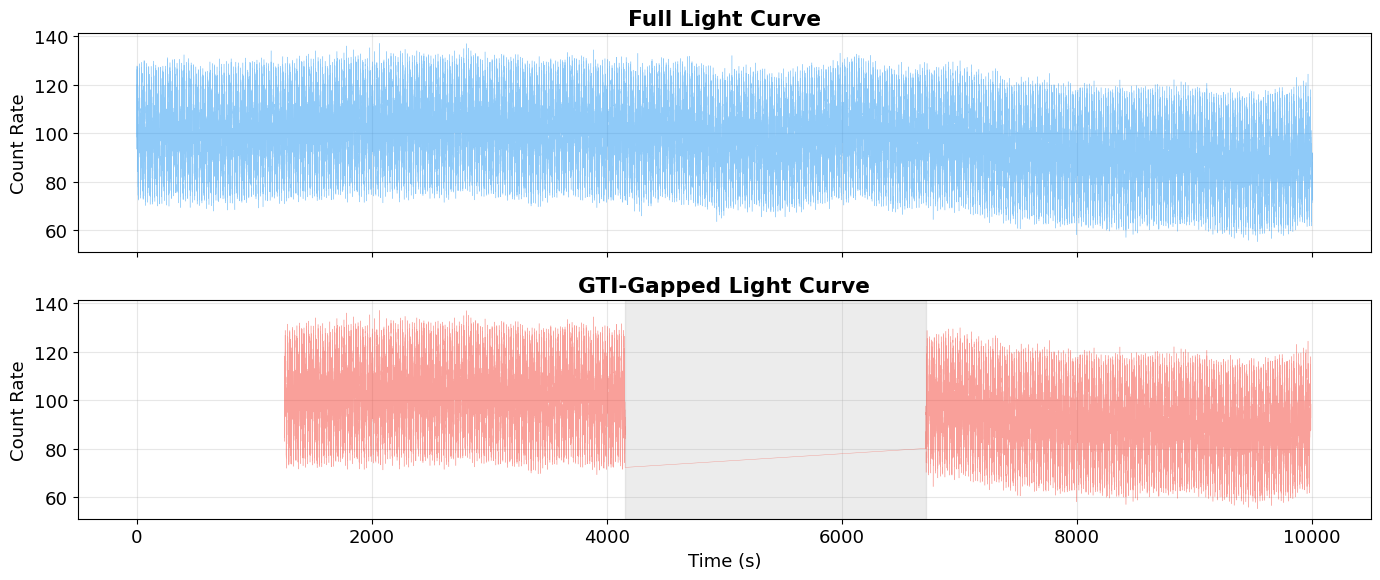

In [3]:
fig, axes = plt.subplots(2, 1, figsize=(14, 6), sharex=True)
axes[0].plot(times_full, counts_full, lw=0.3, color='#2196F3', alpha=0.5)
axes[0].set_ylabel('Count Rate'); axes[0].set_title('Full Light Curve', fontweight='bold')
axes[1].plot(times_gapped, counts_gapped, lw=0.3, color='#F44336', alpha=0.5)
for i in range(len(gti_starts)-1):
    axes[1].axvspan(gti_stops[i], gti_starts[i+1], alpha=0.15, color='gray')
axes[1].set_ylabel('Count Rate'); axes[1].set_xlabel('Time (s)')
axes[1].set_title('GTI-Gapped Light Curve', fontweight='bold')
plt.tight_layout(); plt.show()

## 2. Lomb-Scargle vs FFT Comparison

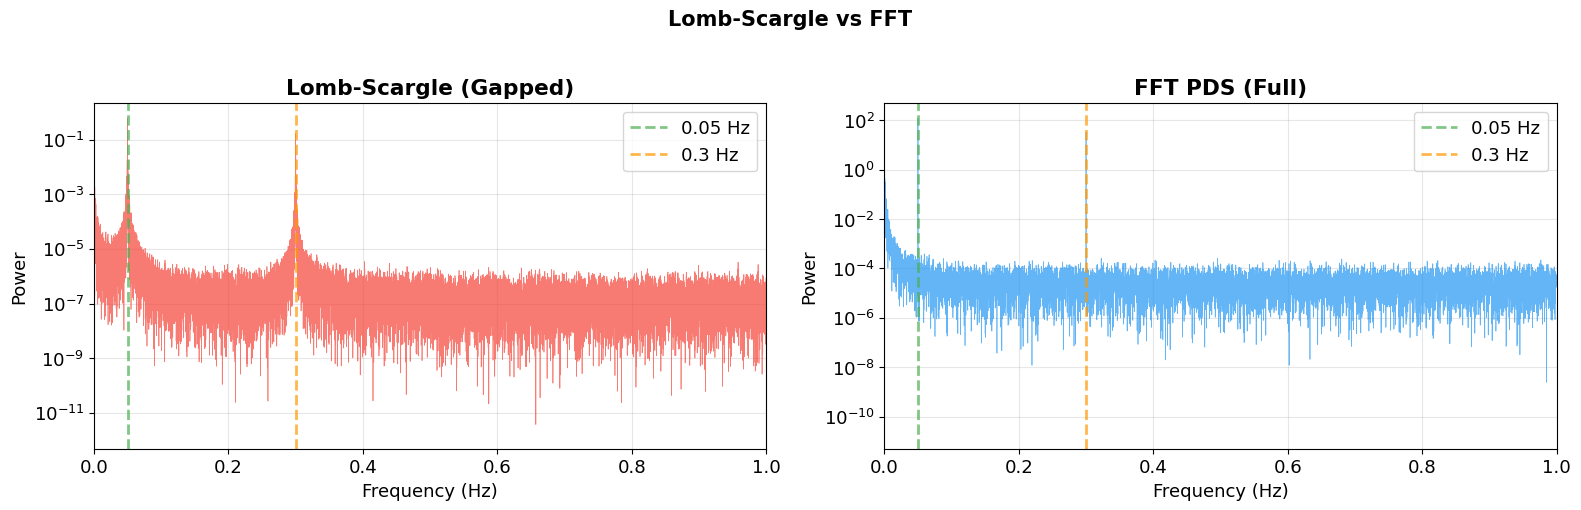

In [4]:
# Lomb-Scargle on gapped data
ls = LombScargle(times_gapped, counts_gapped)
freq_ls, power_ls = ls.autopower(minimum_frequency=1e-4, maximum_frequency=5.0, samples_per_peak=5)

# FFT on full data for comparison
lc_full = Lightcurve(times_full, counts_full, dt=dt)
ps_fft = Powerspectrum(lc_full, norm='frac')

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
for ax, f, p, title, col in zip(axes, [freq_ls, ps_fft.freq], [power_ls, ps_fft.power],
    ['Lomb-Scargle (Gapped)', 'FFT PDS (Full)'], ['#F44336', '#2196F3']):
    ax.semilogy(f, p, lw=0.5, color=col, alpha=0.7)
    ax.axvline(signal_freq1, color='#4CAF50', ls='--', lw=2, alpha=0.7, label=f'{signal_freq1} Hz')
    ax.axvline(signal_freq2, color='#FF9800', ls='--', lw=2, alpha=0.7, label=f'{signal_freq2} Hz')
    ax.set_xlabel('Frequency (Hz)'); ax.set_ylabel('Power')
    ax.set_title(title, fontweight='bold'); ax.legend(); ax.set_xlim(0, 1)
plt.suptitle('Lomb-Scargle vs FFT', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout(); plt.show()

## 3. Significance Testing (False Alarm Probability)

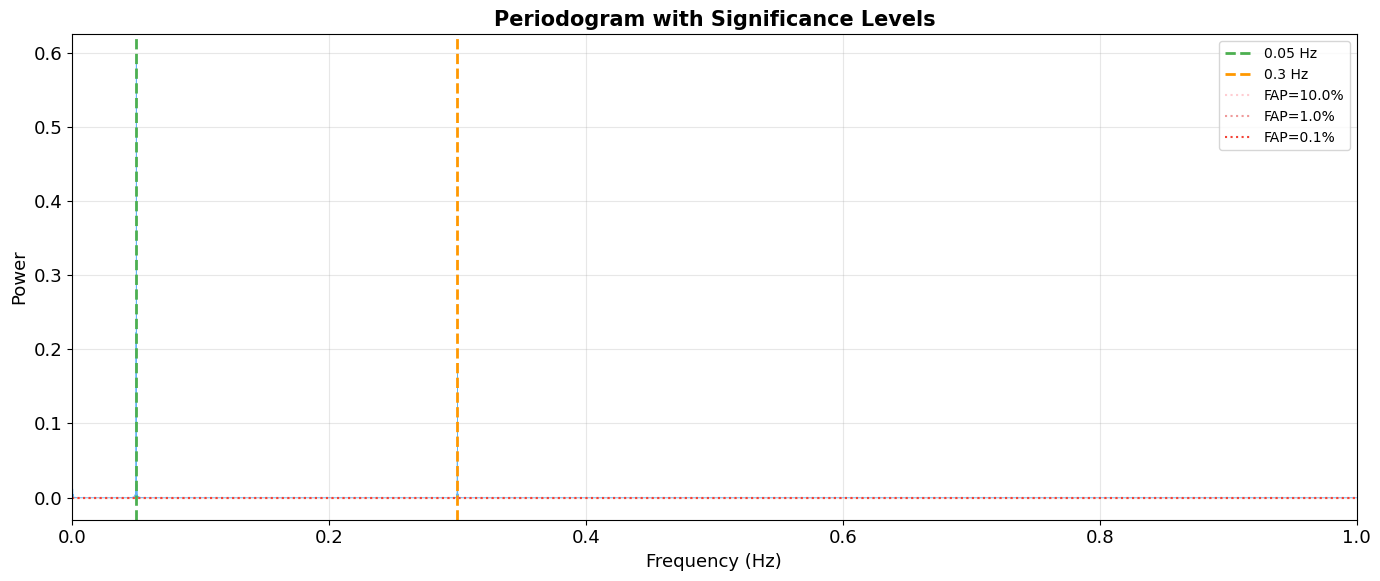

Strongest peak: 0.0500 Hz, FAP = 0.00e+00
✅ Detection SIGNIFICANT


In [5]:
fap_levels = [0.1, 0.01, 0.001]
power_levels = ls.false_alarm_level(fap_levels)

fig, ax = plt.subplots(figsize=(14, 6))
ax.plot(freq_ls, power_ls, lw=0.5, color='#2196F3', alpha=0.7)
ax.axvline(signal_freq1, color='#4CAF50', ls='--', lw=2, label=f'{signal_freq1} Hz')
ax.axvline(signal_freq2, color='#FF9800', ls='--', lw=2, label=f'{signal_freq2} Hz')
for lev, pw, c in zip(fap_levels, power_levels, ['#FFCDD2','#EF9A9A','#F44336']):
    ax.axhline(pw, color=c, ls=':', lw=1.5, label=f'FAP={lev*100:.1f}%')
ax.set_xlabel('Frequency (Hz)'); ax.set_ylabel('Power')
ax.set_title('Periodogram with Significance Levels', fontsize=15, fontweight='bold')
ax.legend(fontsize=10); ax.set_xlim(0, 1); plt.tight_layout(); plt.show()

best_freq = freq_ls[np.argmax(power_ls)]
best_fap = ls.false_alarm_probability(np.max(power_ls))
print(f"Strongest peak: {best_freq:.4f} Hz, FAP = {best_fap:.2e}")
print(f"✅ Detection {'SIGNIFICANT' if best_fap < 0.001 else 'NOT significant'}")